In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [2]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end=now
ticker='AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-03-09,22.901699,23.005880,22.709189,22.944729,108806800
2016-03-10,22.913025,23.155359,22.682016,22.967381,134054400
2016-03-11,23.159893,23.164422,22.987767,23.155362,109632800
2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400
2016-03-15,23.685326,23.821214,23.519994,23.544907,160270800
...,...,...,...,...,...
2026-03-03,263.750000,265.559998,260.130005,263.480011,38568900
2026-03-04,262.519989,266.149994,261.420013,264.649994,39803100


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-03-09,22.901699,23.005880,22.709189,22.944729,108806800
2016-03-10,22.913025,23.155359,22.682016,22.967381,134054400
2016-03-11,23.159893,23.164422,22.987767,23.155362,109632800
2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400
2016-03-15,23.685326,23.821214,23.519994,23.544907,160270800


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-03-03,263.750000,265.559998,260.130005,263.480011,38568900
2026-03-04,262.519989,266.149994,261.420013,264.649994,39803100
2026-03-05,260.290009,261.559998,257.250000,260.790009,49658600
2026-03-06,257.459991,258.769989,254.369995,258.630005,41094000
2026-03-09,256.334991,258.269989,253.680496,255.690002,17613962


# 2. Data Exploration & Visualization

In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
df.shape

(2514, 5)

In [7]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03
mean,118.494206,119.676441,117.202900,118.390531,9.898853e+07
std,74.808808,75.537190,74.023898,74.754929,5.578722e+07
min,20.584818,20.887864,20.386581,20.507340,1.761396e+07
25%,43.388511,43.786120,43.070721,43.388546,6.010780e+07
50%,124.229511,125.463955,122.974165,124.622755,8.705320e+07
75%,174.926498,176.442182,173.009884,174.537327,1.207890e+08
max,285.922455,288.350192,283.035157,285.932471,4.584084e+08


In [9]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [10]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-03-09,22.901699,23.005880,22.709189,22.944729,108806800
2016-03-10,22.913025,23.155359,22.682016,22.967381,134054400
2016-03-11,23.159893,23.164422,22.987767,23.155362,109632800
2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400
2016-03-15,23.685326,23.821214,23.519994,23.544907,160270800


In [11]:
df = df.reset_index()

In [12]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-03-09,22.901699,23.005880,22.709189,22.944729,108806800
1,2016-03-10,22.913025,23.155359,22.682016,22.967381,134054400
2,2016-03-11,23.159893,23.164422,22.987767,23.155362,109632800
3,2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400
4,2016-03-15,23.685326,23.821214,23.519994,23.544907,160270800


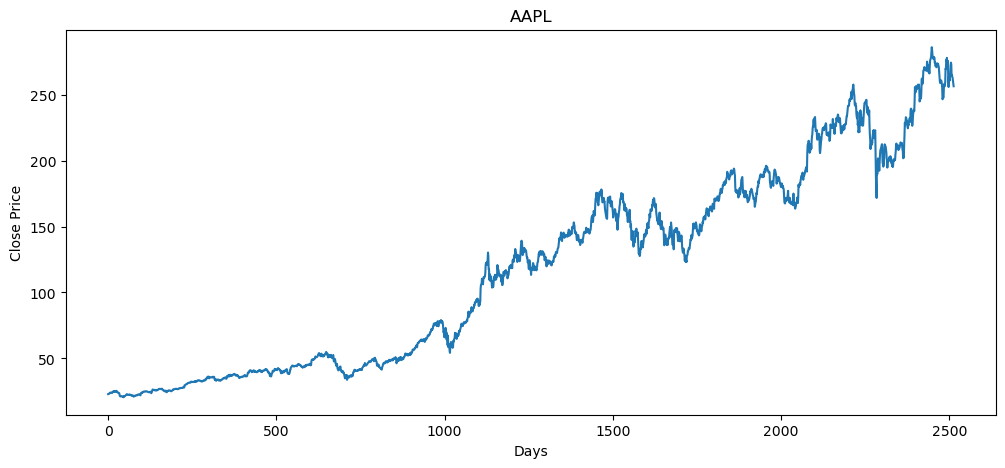

In [13]:
plt.figure(figsize=(12,5));
plt.plot(df.Close);
plt.title(ticker);
plt.xlabel('Days');
plt.ylabel('Close Price');

# 3. Feature Engineering

In [14]:
# 10, 20, 30 ,40, 50, 60, 70 ,80, 90, 100

# MA of 5 days ==> null null null null 30 40 

In [15]:
temp_df = [10, 20, 30 ,40, 50, 60, 70 ,80, 90, 100]
print(sum(temp_df[2:7])/5)

50.0


In [16]:
df1 = pd.DataFrame([10, 20, 30 ,40, 50, 60, 70 ,80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [17]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


# 100 Days Moving Average

In [18]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-03-09,22.901699,23.005880,22.709189,22.944729,108806800,NaN
1,2016-03-10,22.913025,23.155359,22.682016,22.967381,134054400,NaN
2,2016-03-11,23.159893,23.164422,22.987767,23.155362,109632800,NaN
3,2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400,NaN
4,2016-03-15,23.685326,23.821214,23.519994,23.544907,160270800,NaN


In [19]:
df.head(103)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-03-09,22.901699,23.005880,22.709189,22.944729,108806800,NaN
1,2016-03-10,22.913025,23.155359,22.682016,22.967381,134054400,NaN
2,2016-03-11,23.159893,23.164422,22.987767,23.155362,109632800,NaN
3,2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400,NaN
4,2016-03-15,23.685326,23.821214,23.519994,23.544907,160270800,NaN
...,...,...,...,...,...,...,...
98,2016-07-28,23.774849,23.799914,23.428503,23.430782,159479200,NaN
99,2016-07-29,23.745228,23.822701,23.624463,23.740671,110934800,22.768904
100,2016-08-01,24.164492,24.187277,23.790802,23.790802,152671600,22.781532


Text(0, 0.5, 'Price')

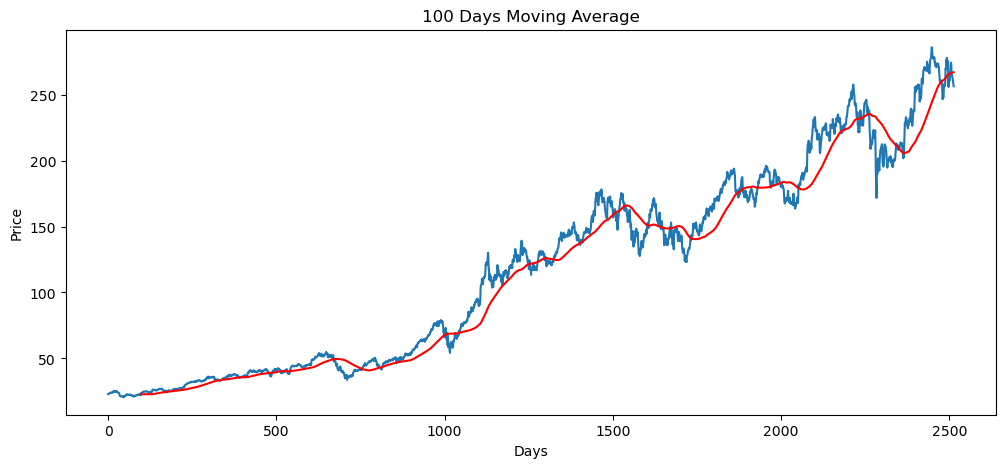

In [20]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')


# 200 Days Moving Average

In [21]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(203)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-03-09,22.901699,23.005880,22.709189,22.944729,108806800,NaN,NaN
1,2016-03-10,22.913025,23.155359,22.682016,22.967381,134054400,NaN,NaN
2,2016-03-11,23.159893,23.164422,22.987767,23.155362,109632800,NaN,NaN
3,2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400,NaN,NaN
4,2016-03-15,23.685326,23.821214,23.519994,23.544907,160270800,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2016-12-19,26.858686,27.029086,26.653746,26.665261,111117600,25.510185,NaN
199,2016-12-20,26.930073,27.056722,26.867901,26.881716,85700000,25.542034,24.155469
200,2016-12-21,26.955399,27.033691,26.890923,26.895530,95132800,25.569943,24.175737


Text(0, 0.5, 'Price')

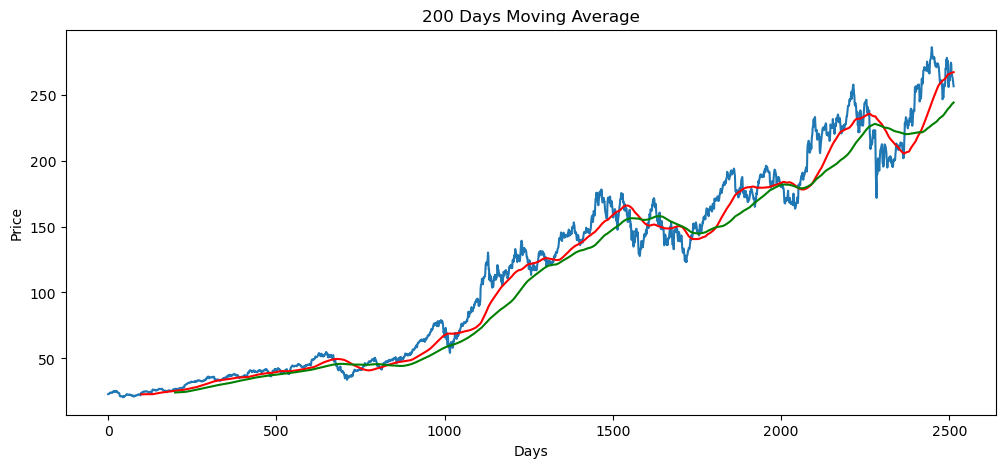

In [22]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('200 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

In [23]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-03-09,22.901699,23.005880,22.709189,22.944729,108806800,NaN,NaN
1,2016-03-10,22.913025,23.155359,22.682016,22.967381,134054400,NaN,NaN
2,2016-03-11,23.159893,23.164422,22.987767,23.155362,109632800,NaN,NaN
3,2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400,NaN,NaN
4,2016-03-15,23.685326,23.821214,23.519994,23.544907,160270800,NaN,NaN
...,...,...,...,...,...,...,...,...
2509,2026-03-03,263.750000,265.559998,260.130005,263.480011,38568900,266.663109,243.020448
2510,2026-03-04,262.519989,266.149994,261.420013,264.649994,39803100,266.712617,243.279006
2511,2026-03-05,260.290009,261.559998,257.250000,260.790009,49658600,266.779951,243.527361


### Calculating % change in each trading session

In [24]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close','Percentage Changed']]

Price,Close,Percentage Changed
Ticker,AAPL,
0,22.901699,NaN
1,22.913025,0.000495
2,23.159893,0.010774
3,23.218777,0.002542
4,23.685326,0.020094
...,...,...
2509,263.750000,-0.003664
2510,262.519989,-0.004664
2511,260.290009,-0.008495


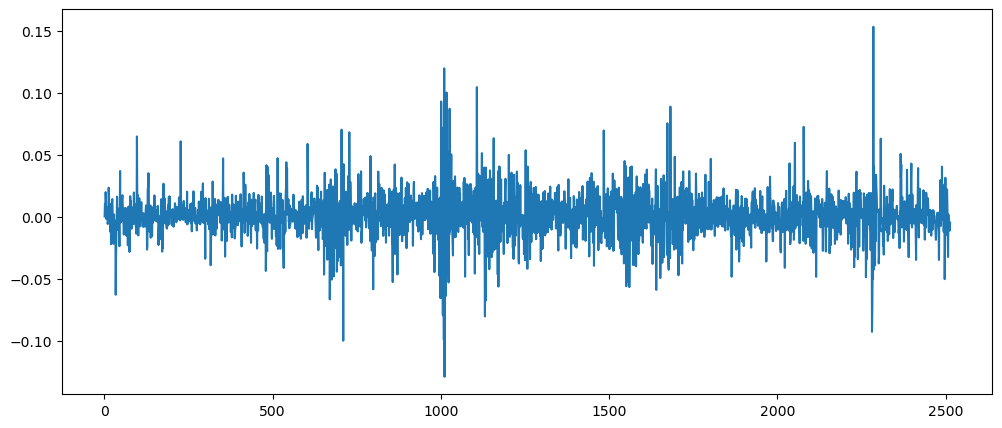

In [25]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage Changed'])

## 4.Date Preprocessing

In [26]:
df.shape

(2514, 9)

In [27]:
# Splitting data into Training & Testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])

print(data_training)
print(data_testing)

Ticker        AAPL
0        22.901699
1        22.913025
2        23.159893
3        23.218777
4        23.685326
...            ...
1754    145.807693
1755    145.304932
1756    143.234940
1757    143.826385
1758    148.873260

[1759 rows x 1 columns]
Ticker        AAPL
1759    151.633270
1760    149.435135
1761    150.686996
1762    148.439529
1763    146.379395
...            ...
2509    263.750000
2510    262.519989
2511    260.290009
2512    257.459991
2513    256.334991

[755 rows x 1 columns]


In [28]:
data_training

Ticker,AAPL
0,22.901699
1,22.913025
2,23.159893
3,23.218777
4,23.685326
...,...
1754,145.807693
1755,145.304932
1756,143.234940
1757,143.826385


In [29]:
data_testing

Ticker,AAPL
1759,151.633270
1760,149.435135
1761,150.686996
1762,148.439529
1763,146.379395
...,...
2509,263.750000
2510,262.519989
2511,260.290009
2512,257.459991


In [30]:
# Scaling dowm the data between 0 and 1

In [31]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [32]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.0147086 ],
       [0.0147805 ],
       [0.01634773],
       ...,
       [0.77863782],
       [0.78239258],
       [0.8144324 ]])

In [33]:
type(data_training_array)

numpy.ndarray

In [34]:
data_training_array.shape

(1759, 1)

# 5. Sequence Creation

In [35]:
# --> x-train 12, 15, 16, 17, 18, 19, 20, 21, 22, 24      23  <--Y-train

In [36]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [37]:
x_train

array([[[0.0147086 ],
        [0.0147805 ],
        [0.01634773],
        ...,
        [0.01824103],
        [0.02025174],
        [0.0200637 ]],

       [[0.0147805 ],
        [0.01634773],
        [0.01672155],
        ...,
        [0.02025174],
        [0.0200637 ],
        [0.02272537]],

       [[0.01634773],
        [0.01672155],
        [0.01968341],
        ...,
        [0.0200637 ],
        [0.02272537],
        [0.02045424]],

       ...,

       [[0.78254699],
        [0.77649642],
        [0.74318586],
        ...,
        [0.7873987 ],
        [0.79497081],
        [0.79177905]],

       [[0.77649642],
        [0.74318586],
        [0.74524463],
        ...,
        [0.79497081],
        [0.79177905],
        [0.77863782]],

       [[0.74318586],
        [0.74524463],
        [0.73626191],
        ...,
        [0.79177905],
        [0.77863782],
        [0.78239258]]])

In [38]:
x_train.ndim

3

In [39]:
y_train.ndim

1

In [40]:
x_train.shape

(1659, 100, 1)

In [41]:
y_train.shape

(1659,)

In [42]:
x_train.ndim

3

# 6. Model Building

In [43]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [44]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [45]:
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7.Model Training

In [46]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 22s 237ms/step - loss: 0.0201
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step - loss: 6.5926e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - loss: 6.3408e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 244ms/step - loss: 6.0728e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 240ms/step - loss: 5.9426e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 237ms/step - loss: 5.8122e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - loss: 5.8364e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 189ms/step - loss: 5.3213e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - loss: 6.0849e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - loss: 5.5349e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 288ms/step - loss: 4.9400e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 268ms/step - loss: 4.8897e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 260ms/step - loss: 5.3190e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 266ms/step - loss: 4.

In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [48]:
# Save the traines model
model.save('stock_prediction_model.keras')

# 8.Preparing Test Data

In [49]:
data_training.tail(100)

Ticker,AAPL
1659,137.974884
1660,136.559937
1661,135.931091
1662,140.500137
1663,135.970428
...,...
1754,145.807693
1755,145.304932
1756,143.234940
1757,143.826385


In [50]:
data_testing

Ticker,AAPL
1759,151.633270
1760,149.435135
1761,150.686996
1762,148.439529
1763,146.379395
...,...
2509,263.750000
2510,262.519989
2511,260.290009
2512,257.459991


In [51]:
past_100_days = data_training.tail(100)

In [52]:
past_100_days

Ticker,AAPL
1659,137.974884
1660,136.559937
1661,135.931091
1662,140.500137
1663,135.970428
...,...
1754,145.807693
1755,145.304932
1756,143.234940
1757,143.826385


In [53]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,137.974884
1,136.559937
2,135.931091
3,140.500137
4,135.970428
...,...
850,263.750000
851,262.519989
852,260.290009
853,257.459991


In [54]:
input_data = scaler.fit_transform(final_df)
input_data

array([[9.16533054e-02],
       [8.29660192e-02],
       [7.91051280e-02],
       [1.07157484e-01],
       [7.93466445e-02],
       [1.03658492e-01],
       [1.11742362e-01],
       [1.12405830e-01],
       [1.09570494e-01],
       [1.32977451e-01],
       [1.46128857e-01],
       [1.63563762e-01],
       [1.45525535e-01],
       [1.18076596e-01],
       [1.84074957e-01],
       [1.69596241e-01],
       [1.53368169e-01],
       [1.19464238e-01],
       [8.23629775e-02],
       [8.07314764e-02],
       [8.39943848e-02],
       [8.74992781e-02],
       [5.95213074e-02],
       [1.32034150e-01],
       [1.49135166e-01],
       [1.40554492e-01],
       [1.51189743e-01],
       [1.43636123e-01],
       [1.55298989e-01],
       [1.58743269e-01],
       [1.38922804e-01],
       [1.52035613e-01],
       [1.57413992e-01],
       [1.39527251e-01],
       [1.16020989e-01],
       [9.75906950e-02],
       [1.39043749e-01],
       [1.40735770e-01],
       [1.37714659e-01],
       [1.30584021e-01],


In [55]:
input_data.shape

(855, 1)

In [56]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100 : i])
    y_test.append(input_data[i,0])

In [57]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [58]:
x_test

array([[[0.09165331],
        [0.08296602],
        [0.07910513],
        ...,
        [0.12394822],
        [0.12757949],
        [0.15856555]],

       [[0.08296602],
        [0.07910513],
        [0.10715748],
        ...,
        [0.12757949],
        [0.15856555],
        [0.17551105]],

       [[0.07910513],
        [0.10715748],
        [0.07934664],
        ...,
        [0.15856555],
        [0.17551105],
        [0.16201526]],

       ...,

       [[0.80128552],
        [0.74754332],
        [0.76218917],
        ...,
        [0.8698243 ],
        [0.86386883],
        [0.85631699]],

       [[0.74754332],
        [0.76218917],
        [0.76286322],
        ...,
        [0.86386883],
        [0.85631699],
        [0.84262568]],

       [[0.76218917],
        [0.76286322],
        [0.77248416],
        ...,
        [0.85631699],
        [0.84262568],
        [0.82525036]]])

# 9.Making Predictions

In [59]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step


In [60]:
y_predicted

array([[0.14455253],
       [0.15634812],
       [0.1643021 ],
       [0.17107493],
       [0.17219852],
       [0.16784437],
       [0.1655355 ],
       [0.16753653],
       [0.17112423],
       [0.17887487],
       [0.18485622],
       [0.19260058],
       [0.20194735],
       [0.20715396],
       [0.21140653],
       [0.21622795],
       [0.21670742],
       [0.21458177],
       [0.21703024],
       [0.2228076 ],
       [0.23243998],
       [0.24304098],
       [0.25037605],
       [0.25158957],
       [0.25191212],
       [0.24723704],
       [0.24011658],
       [0.23280364],
       [0.23621528],
       [0.2416033 ],
       [0.24658595],
       [0.25234506],
       [0.2588163 ],
       [0.2621615 ],
       [0.26087543],
       [0.25889286],
       [0.25442716],
       [0.25030115],
       [0.2550614 ],
       [0.26353464],
       [0.27104986],
       [0.274599  ],
       [0.27406964],
       [0.26945254],
       [0.27792695],
       [0.28793398],
       [0.29301086],
       [0.298

In [61]:
y_test

array([0.17551105, 0.16201526, 0.16970126, 0.15590259, 0.14325408,
       0.15517664, 0.16800643, 0.17042759, 0.18773612, 0.18259176,
       0.19711638, 0.20849435, 0.19971891, 0.20637607, 0.21436467,
       0.2024422 , 0.19862946, 0.21751178, 0.22713431, 0.2425063 ,
       0.25019248, 0.24692452, 0.23560725, 0.24105411, 0.22513735,
       0.21769343, 0.21345706, 0.24650079, 0.2443826 , 0.24450354,
       0.25200807, 0.25902854, 0.25309752, 0.24323263, 0.24510865,
       0.23566777, 0.23560725, 0.26374879, 0.27143479, 0.2708902 ,
       0.26453555, 0.257939  , 0.24789283, 0.29497702, 0.29455348,
       0.28408377, 0.2949166 , 0.29606638, 0.29036957, 0.28733956,
       0.28733956, 0.29109702, 0.30539924, 0.30606608, 0.30024814,
       0.28424875, 0.28594545, 0.29291505, 0.30770236, 0.31903508,
       0.31873211, 0.33594349, 0.34115539, 0.33285286, 0.33061045,
       0.32218651, 0.33885246, 0.3412161 , 0.35836676, 0.35545779,
       0.35933639, 0.37182077, 0.36521495, 0.36576028, 0.35939

In [62]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [63]:
y_predicted

array([146.59088, 148.5121 , 149.8076 , 150.91074, 151.09373, 150.38455,
       150.0085 , 150.33441, 150.91876, 152.18115, 153.15538, 154.41675,
       155.9391 , 156.78712, 157.47977, 158.26506, 158.34315, 157.99695,
       158.39574, 159.33673, 160.90561, 162.63225, 163.82697, 164.0246 ,
       164.07715, 163.31569, 162.15594, 160.96484, 161.52051, 162.39809,
       163.20964, 164.14766, 165.20168, 165.74652, 165.53705, 165.21414,
       164.48679, 163.81476, 164.59009, 165.97017, 167.19421, 167.77228,
       167.68607, 166.93405, 168.31432, 169.94423, 170.77112, 171.64322,
       172.31348, 172.4536 , 172.2331 , 171.93813, 171.85855, 172.53374,
       173.28761, 173.60289, 172.94427, 172.24786, 172.03004, 172.71027,
       174.03238, 175.202  , 176.85788, 178.44585, 179.1583 , 179.28152,
       178.7369 , 178.93195, 179.36456, 180.60335, 181.58379, 182.42223,
       183.5936 , 184.17014, 184.43152, 184.17268, 184.7503 , 185.26913,
       185.20079, 185.84563, 186.8499 , 187.7821 , 

In [64]:
y_test

array([151.63327026, 149.43513489, 150.68699646, 148.43952942,
       146.37939453, 148.32128906, 150.41094971, 150.80529785,
       153.62443542, 152.7865448 , 155.1522522 , 157.00544739,
       155.57614136, 156.66043091, 157.96157837, 156.0196991 ,
       155.3986969 , 158.47416687, 160.04144287, 162.54516602,
       163.79705811, 163.26478577, 161.42147827, 162.30863953,
       159.71618652, 158.50375366, 157.81375122, 163.19577026,
       162.85076904, 162.87046814, 164.09277344, 165.23623657,
       164.2702179 , 162.66346741, 162.96902466, 161.43133545,
       161.42147827, 166.00505066, 167.25691223, 167.16821289,
       166.13319397, 165.05877686, 163.42250061, 171.09136963,
       171.02238464, 169.31712341, 171.08152771, 171.26879883,
       170.34092712, 169.84741211, 169.84741211, 170.45941162,
       172.78889465, 172.89750671, 171.9499054 , 169.34399414,
       169.62034607, 170.75552368, 173.16401672, 175.00984192,
       174.960495  , 177.7638092 , 178.61270142, 177.26

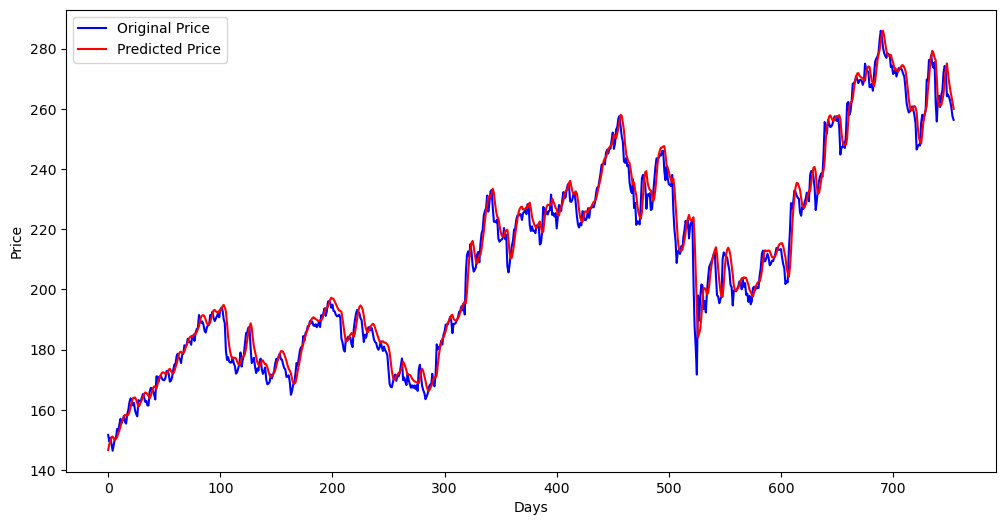

In [65]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(140.0, 300.0)

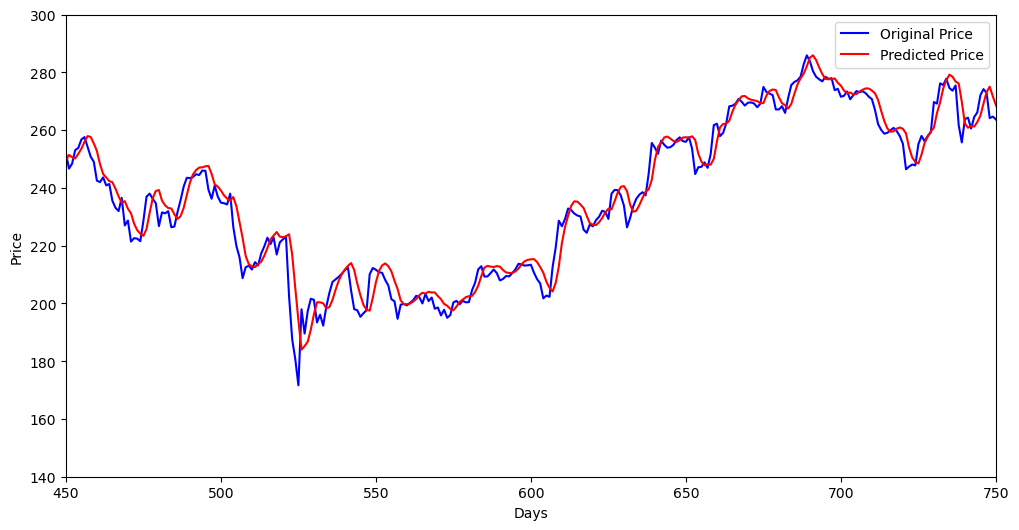

In [66]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750)
plt.ylim(140, 300)

# 10. Model Evaluation

In [67]:
# Mean Squared Error (MSE
from sklearn.metrics import mean_squared_error, r2_score

In [68]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 21.24502375543808


In [69]:
# Root Mean Squared Error (RMSE
rmse = np.sqrt(mse)
print(f" Root Mean Squared Error (RMSE): {rmse}")

 Root Mean Squared Error (RMSE): 4.609232447538102


In [70]:
# R-Squared
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9812578360071953
